# Molecular representations with CORDS

This notebook follows a molecular roundtrip through CORDS: we encode atom positions and element labels as continuous fields, evaluate the fields at sampled locations, and reconstruct the atoms. We then use the same representation in a small molecular denoising example to show how a model can be trained.

From the repository root, install the dependencies with `python -m pip install -r requirements.txt` and launch `python -m jupyter lab notebooks/`. Select the corresponding Python kernel and run the cells in order. The examples use three bundled QM9 structures, so they can run offline once the dependencies are available. Static figures are included for reading on GitHub, and interactive views are available in JupyterLab.

The structures include explicit hydrogens, with coordinates in Å and source indices recorded in the data file. Reconstruction recovers atom positions and element labels. The bonds shown in the source structures come from QM9 annotations; inferring bond topology would require an additional step.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "cords").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import math
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(2)
%matplotlib inline
RUN_TRAINING = False  # Enable the optional training section below.
from cords import CORDSTransform
from cords.molecules import load_qm9_examples, reconstruction_metrics
from cords.visualization import plot_molecule_roundtrip, plot_molecular_slice, interactive_molecule

molecules = load_qm9_examples()
[(m.name, m.source_index, len(m.positions)) for m in molecules]

[('gdb_14', 13, 9), ('gdb_19', 18, 9), ('gdb_826', 825, 7)]

## 1. Encoding molecular structures

For a molecule with atom positions $\mathbf r_i$ and one-hot element vectors $\mathbf x_i$ over H, C, N, O and F, we place a unit-integral Gaussian at each atom:

$$\kappa_\sigma(\mathbf r-\mathbf r_i)=(2\pi\sigma^2)^{-3/2}\exp[-\|\mathbf r-\mathbf r_i\|^2/(2\sigma^2)].$$

Summing these kernels gives a density field, while weighting them by the element vectors gives the feature fields:

$$\rho(\mathbf r)=\sum_i\kappa_\sigma(\mathbf r-\mathbf r_i),\qquad \mathbf h(\mathbf r)=\sum_i\kappa_\sigma(\mathbf r-\mathbf r_i)\mathbf x_i.$$

Because each kernel has unit integral, the total density mass equals the number of atoms, $\int\rho(\mathbf r)\,d\mathbf r=N$. The integral of each feature channel likewise equals the number of atoms of that element. The bandwidth $\sigma$ controls how broadly each atom contributes to the field while preserving these integrals.

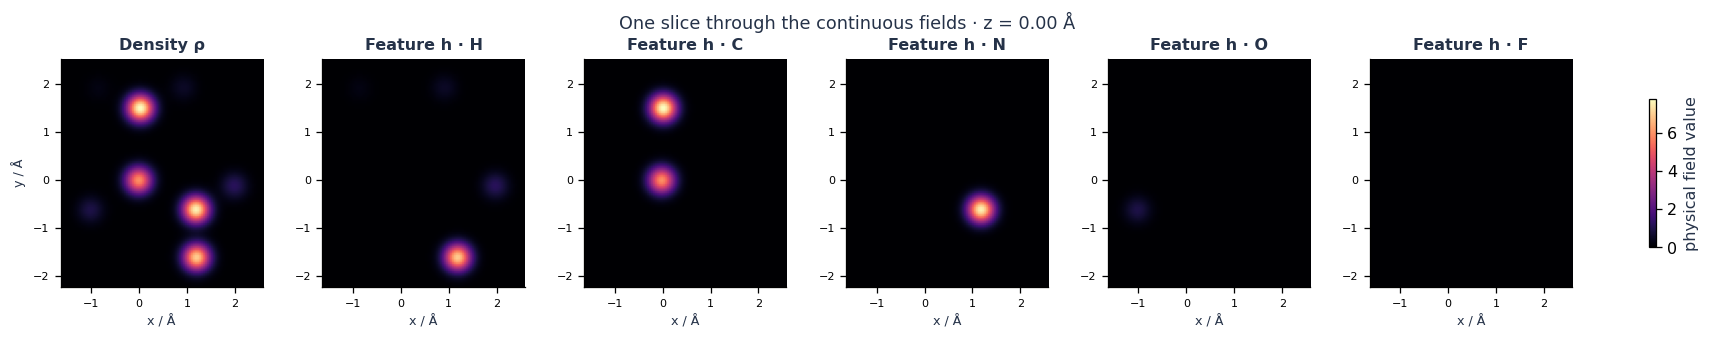

In [2]:
molecule = molecules[1]  # gdb_19: H, C, N and O
transform = CORDSTransform(sigma=0.2, seed=0)
fields = transform.encode(molecule.positions, molecule.features, num_samples=1024)
fig = plot_molecular_slice(molecule, transform)
plt.show()

## 2. Sampling the fields

To represent the fields with a finite set of values, we draw $S$ locations from the Gaussian-mixture proposal $q(\mathbf r)=N^{-1}\sum_i\kappa_\sigma(\mathbf r-\mathbf r_i)$. Importance sampling concentrates evaluations near the atoms, where most of the field mass lies. We store the sampled coordinates, density and feature values, together with quadrature weights $w_s=1/[S q(\mathbf r_s)]$.

These weights allow us to estimate the density integral and hence the atom count:

$$\widehat N=\sum_s w_s\rho(\mathbf r_s).$$

For this proposal, $\rho/q=N$ at every sampled location, so the count estimate is exact up to floating-point arithmetic. The weights account for the nonuniform sampling distribution; simply averaging the physical density values would give a different quantity. The decoder receives the sampled fields and their integration weights, and infers the count and atom positions from them.

Fields produced by a generative model have no known source proposal. The training section below introduces the density normalization used for that setting.

In [3]:
print(f"Raw density mean: {fields.density.mean().item():.6f}")
print(f"Importance-weighted mass: {fields.count_estimate():.6f}")
print(f"Field arrays: coordinates {tuple(fields.coordinates.shape)}, "
      f"density {tuple(fields.density.shape)}, features {tuple(fields.features.shape)}")
assert abs(fields.count_estimate() - len(molecule.positions)) < 1e-8

Raw density mean: 2.769123
Importance-weighted mass: 9.000000
Field arrays: coordinates (1024, 3), density (1024, 1), features (1024, 5)


## 3. Reconstructing atoms from fields

The decoder rounds the estimated density integral to obtain the number of atoms and initializes their positions with a custom Gaussian mixture model whose bandwidth is fixed to the encoding bandwidth. Weighted expectation-maximization accounts for the integration weights when fitting the mixture, followed by L-BFGS refinement against the sampled density.

Once the centers $\widehat{\mathbf r}_i$ have been fitted, we evaluate the kernel matrix $A_{si}=\kappa_\sigma(\mathbf r_s-\widehat{\mathbf r}_i)$ and recover the atom features jointly:

$$\widehat X=(A^\top W A+\lambda I)^{-1}A^\top W H.$$

Here, $H$ contains the sampled feature values and $W$ is the diagonal matrix of integration weights. The implementation solves this linear system with a small regularization term scaled to the Gram matrix. The largest component of each recovered feature vector determines its element label.

Fitting the centers is a nonconvex optimization problem, so the numerical reconstruction can fail even when the continuous representation is invertible in principle. We compare the recovered atoms with the source structure and report density and feature residuals to assess the reconstruction.

{'true_count': 9, 'decoded_count': 9, 'count_correct': True, 'position_rms_angstrom': 1.1390480036690024e-07, 'max_position_error_angstrom': 1.9490816414263257e-07, 'type_accuracy': 1.0}
{'gram_condition_number': 1.2792537016685384, 'density_relative_error': 3.4639853611733065e-07, 'feature_relative_error': 3.5105217232958947e-07}


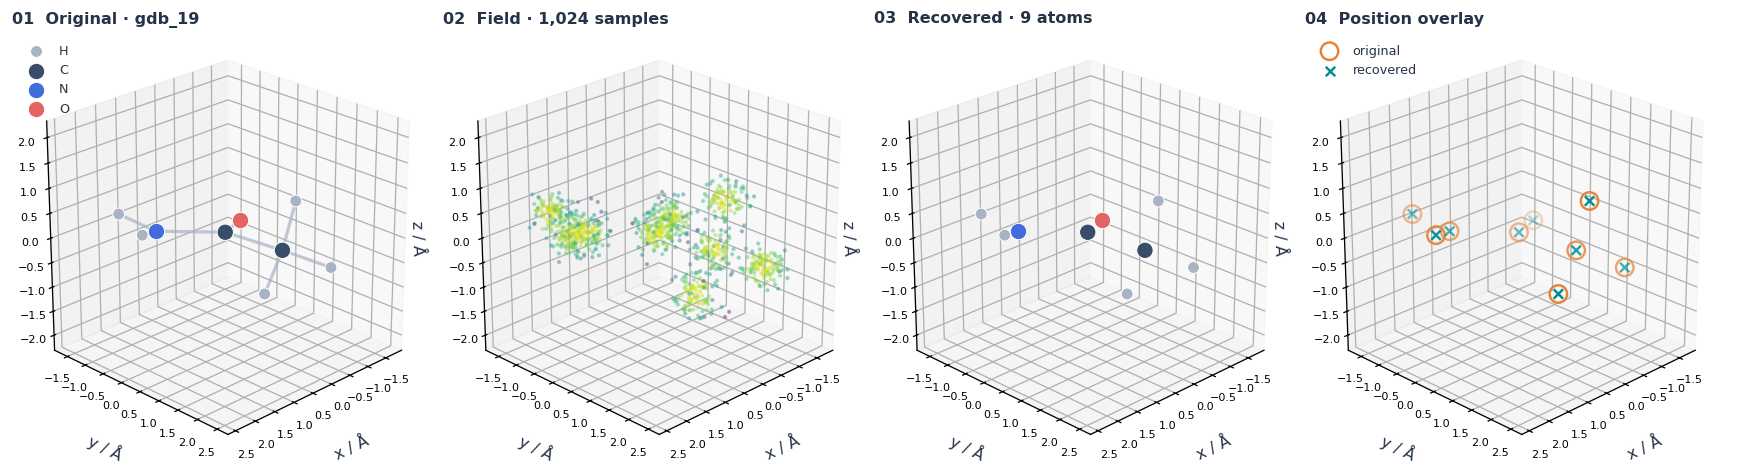

In [4]:
with torch.no_grad():
    decoded = transform.decode(fields)
metrics = reconstruction_metrics(molecule, decoded)
print(metrics)
print({key: value for key, value in decoded.diagnostics.items()
       if key in ("density_relative_error", "feature_relative_error", "gram_condition_number")})
assert metrics["count_correct"] and metrics["type_accuracy"] == 1.0
assert metrics["position_rms_angstrom"] < 0.02
fig = plot_molecule_roundtrip(molecule, fields, decoded)
plt.show()

## 4. Exploring the reconstruction

The interactive view shows the source atoms, sampled fields and reconstructed atoms in the same coordinate system. Drag the scene to rotate it, or select legend entries to change which elements are visible. The static overlay above provides another view of the same reconstruction.

In [5]:
interactive_molecule(molecule, fields, decoded).show(renderer="plotly_mimetype")

In [6]:
import ipywidgets as widgets

molecule_choice = widgets.Dropdown(options=[(m.name, i) for i, m in enumerate(molecules)], value=1, description="Molecule")
bandwidth = widgets.FloatSlider(value=0.2, min=0.10, max=0.6, step=0.05, description="σ / Å", continuous_update=False)
sample_count = widgets.Dropdown(options=[256, 512, 1024, 2048], value=1024, description="Samples")
recompute = widgets.Button(description="Recompute roundtrip", button_style="info")
exploration = widgets.Output()

def update_molecule(_):
    with exploration:
        exploration.clear_output(wait=True)
        selected = molecules[molecule_choice.value]
        conversion = CORDSTransform(sigma=bandwidth.value, seed=0)
        sampled = conversion.encode(selected.positions, selected.features, num_samples=sample_count.value)
        recovered = conversion.decode(sampled)
        print(reconstruction_metrics(selected, recovered))
        print("Density residual:", recovered.diagnostics["density_relative_error"])
        interactive_molecule(selected, sampled, recovered).show(renderer="plotly_mimetype")

recompute.on_click(update_molecule)
display(widgets.VBox([widgets.HBox([molecule_choice, sample_count]), bandwidth, recompute, exploration]))

Increasing the Gaussian bandwidth or reducing the number of samples can make nearby atom contributions harder to separate. The controls let you explore how these choices affect the recovered count, matched position and element errors, and field residuals. Comparing these measurements helps distinguish an accurate reconstruction from one that only appears similar in the visualization.

## 5. Density normalization for molecular learning

The molecular training procedure rescales the sampled density so that its arithmetic mean equals the atom count:

$$\widetilde\rho_s=\rho_s\,\frac{N}{S^{-1}\sum_t\rho_t}.$$

The feature fields retain their physical values. With this preprocessing, the model jointly learns sampled coordinates, log density and feature values, and the mean predicted density provides a count estimate during generation.

Decoding a generated field also requires an estimate of its physical density scale and integration weights. The decoder fits the density amplitude while refining the centers, then estimates the proposal weights from the recovered centers for feature reconstruction. These approximations are recorded in the decoding diagnostics.

In [7]:
model_fields = transform.encode(molecule.positions, molecule.features, num_samples=1024,
                                density_mode="count_normalized")
print("Mean count-normalized density:", model_fields.count_estimate())
print("Feature fields stay physical:", torch.allclose(model_fields.features, fields.features))
print("Recover physical density:", torch.allclose(model_fields.density * model_fields.density_scale, fields.density))

Mean count-normalized density: 9.000000000000002
Feature fields stay physical: True
Recover physical density: True


## 6. Training a molecular denoising model

Set `RUN_TRAINING = True` in the setup cell to train on the bundled molecules. The example uses a local PyTorch implementation of the Erwin tree-attention architecture with a joint EDM objective for sampled coordinates, density and feature values. It runs directly from this repository without a separate Erwin installation or compiled tree extension.

Training on this small fixed batch illustrates the optimization procedure and checkpoint workflow. Evaluating molecular generation quality or reproducing the paper's results requires a larger dataset and a separate evaluation. The checkpoint saves the model configuration, normalization, optimizer state and weights.

For training on a larger local dataset, run `python -m cords.train qm9 --full-data --data /path/to/qm9.json --output runs/qm9` from the repository root. The README describes the input formats and how to resume training.

In [8]:
if RUN_TRAINING:
    from cords.train import train_overfit, load_checkpoint
    from cords.visualization import plot_training_history, plot_learning_example
    device = "cuda" if torch.cuda.is_available() else "cpu"
    learned = train_overfit("qm9", steps=80, output=REPO_ROOT / "runs/qm9-notebook", device=device)
    plot_training_history(learned["history"])
    plt.show()
    plot_learning_example(learned)
    plt.show()
    reloaded_model, checkpoint = load_checkpoint(learned["checkpoint"], device=device)
    print("Saved and reloaded:", learned["checkpoint"])
else:
    print("Set RUN_TRAINING = True to run the molecular training example.")

Set RUN_TRAINING = True to run the molecular training example.


After training, you can sample fields from the saved checkpoint with `python -m cords.sample --checkpoint runs/qm9-notebook/checkpoint.pt --output runs/qm9-samples.pt`, run from the repository root. A model fitted to a few molecules may produce inaccurate fields or implausible structures, so decoded samples should be assessed using the reconstruction diagnostics and appropriate chemical checks.

Further details are available in the [CORDS paper](https://arxiv.org/abs/2601.21583), [implementation provenance](../docs/provenance.md), and [data source documentation](../cords/data/README.md).